# Regression with Earth Engine Package

# Import packages

In [1]:
import geopandas as gpd
import pandas as pd
import random
# import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import PredictionErrorDisplay
import os
import math
from itertools import product
import ee
# import geemap
import json

## Initialize and authenticate Earth Engine

In [2]:
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-curuai')

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# Export directory

In [4]:
export_dir = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\TSS Modeling'
# export_dir ='/content/TSS Modeling'
# os.makedirs(export_dir, exist_ok=False)

# Import data

In [5]:
# import directory
data_directory = r'C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Landsat Sampling\Merged Landsat Data'
# data_directory = '/content'

In [6]:
# import data as dataframe
df = pd.read_csv(os.path.join(data_directory,'min_date.csv'))
df = df.drop(columns=['Unnamed: 0', 'CHLOROPHYLL',
                      'CHLOROPHYLL_B', 'DOC', 'dif_date_point',
                      'N_TOTAL', 'N_TOTAL_DISSOLVED',
                      'POC', 'P_ORGANIC', 'P_TOTAL',
                      'SILICA',  'TOC', 'duplicated'],axis=1).rename(columns={'SPM':"TSS"})
df.columns

Index(['CHLOROPHYLL_A', 'CLOUD_COVER', 'DEPTH_CLASS', 'ID', 'LATITUDE',
       'LOCATION', 'LONGITUDE', 'MISSION', 'SAMPLE_SITE', 'SAMPLING_DEPTH',
       'TSS', 'TOTAL_DEPTH', 'TURBIDITY', 'WATER_PERIOD', 'blue_max',
       'blue_mean', 'blue_median', 'blue_min', 'blue_stdDev', 'count_pixel',
       'datetime', 'green_max', 'green_mean', 'green_median', 'green_min',
       'green_stdDev', 'img_date', 'nir_max', 'nir_mean', 'nir_median',
       'nir_min', 'nir_stdDev', 'red_max', 'red_mean', 'red_median', 'red_min',
       'red_stdDev', 'system_index', 'dif_date_point_abs', 'satellite'],
      dtype='object')

# Data Preparation

In [7]:
# filter parameters that will be used in the models
df_subset = df[['TSS','blue_mean',
       'green_mean',
       'nir_mean',
       'red_mean',
       'datetime',
       'WATER_PERIOD',
       'LOCATION',
       'LONGITUDE',
       'LATITUDE']].copy()
# remove empty values
df_subset = df_subset.dropna()
df_subset.isna().sum()

TSS             0
blue_mean       0
green_mean      0
nir_mean        0
red_mean        0
datetime        0
WATER_PERIOD    0
LOCATION        0
LONGITUDE       0
LATITUDE        0
dtype: int64

In [8]:
# obtain date from datetime
df_subset['date'] = df_subset['datetime'].apply(lambda row: row[:10])
df_subset['nir_red_ratio'] = df_subset.apply(lambda row: float(row['nir_mean'] / row['red_mean']), axis=1)
df_subset['red_nir_ratio'] = df_subset.apply(lambda row: float(row['red_mean'] / row['nir_mean']), axis=1)

In [9]:
n = 0
df_subset['LOC'] = df_subset['LOCATION'].copy()
for i in df_subset['LOCATION'].unique():
    df_subset['LOC'] = df_subset['LOC'].replace(i,n)
    n += 1

df_subset["LOC"] = df_subset["LOC"].astype('int8')

C:\Users\l_v_v\AppData\Local\Temp\ipykernel_22488\3041617090.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset['LOC'] = df_subset['LOC'].replace(i,n)


In [10]:
n = 0
df_subset['PERIOD'] = df_subset['WATER_PERIOD'].copy()
for i in df_subset['WATER_PERIOD'].unique():
    df_subset['PERIOD'] = df_subset['PERIOD'].replace(i,n)
    n += 1

df_subset["PERIOD"] = df_subset["PERIOD"].astype('int8')

C:\Users\l_v_v\AppData\Local\Temp\ipykernel_22488\2258988468.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset['PERIOD'] = df_subset['PERIOD'].replace(i,n)


In [11]:
#transform dataframe in a geodataframe (geometry column with point location)
gdf = gpd.GeoDataFrame(
    df_subset, geometry=gpd.points_from_xy(df_subset.LONGITUDE, df_subset.LATITUDE),
    crs="EPSG:4326"
)
gdf.head()

,TSS,blue_mean,green_mean,nir_mean,red_mean,datetime,WATER_PERIOD,LOCATION,LONGITUDE,LATITUDE,date,nir_red_ratio,red_nir_ratio,LOC,PERIOD,geometry
0,34.4,0.014865,0.025426,0.017437,0.033052,2013-03-09 11:20:00,R,LG,-55.299530,-2.196960,2013-03-09,0.527583,1.895435,0,0,POINT (-55.29953 -2.19696)
1,44.4,0.017526,0.029125,0.012897,0.034728,2013-03-09 13:00:00,R,LG,-55.270194,-2.221738,2013-03-09,0.371377,2.692678,0,0,POINT (-55.27019 -2.22174)
2,44.8,0.013158,0.017679,0.009508,0.021370,2013-03-09 14:35:00,R,LG,-55.347110,-2.209570,2013-03-09,0.444932,2.247532,0,0,POINT (-55.34711 -2.20957)
3,45.2,0.031600,0.038987,0.020354,0.043502,2013-03-11 08:00:00,R,PQ,-55.456187,-2.262023,2013-03-11,0.467882,2.137292,1,0,POINT (-55.45619 -2.26202)
4,39.6,0.019097,0.024614,0.012881,0.027611,2013-03-11 11:20:00,R,GP,-55.490867,-2.175347,2013-03-11,0.466504,2.143605,2,0,POINT (-55.49087 -2.17535)


In [12]:
##Convert geodataframe to json - necessary to be read in GEE
dataset_json = gdf.to_json()

In [13]:
#load and select the features of the json data
reg_data = json.loads(dataset_json)
reg_data = reg_data['features']
# data_points

In [14]:
##transform json in in gee object = feature collection
reg_data = ee.FeatureCollection(reg_data)
print(reg_data.size().getInfo())

202


# Model Evaluation Functions

In [15]:
def model_metrics(y_true,y_pred):
    ''' y = observed target values
    y_pred = predicted target values'''
    from sklearn.metrics import r2_score
    from sklearn.metrics import mean_absolute_error
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import mean_absolute_percentage_error
    from sklearn.metrics import explained_variance_score

    return {'r2':r2_score(y_true, y_pred),
'mae':mean_absolute_error(y_true, y_pred),
'mse':mean_squared_error(y_true, y_pred),
'mape':mean_absolute_percentage_error(y_true, y_pred),
'exp_var': explained_variance_score(y_true, y_pred)
    }

In [16]:
def best_by_mae_then_r2(list_metrics, tol=1e-9):
    min_mae = min(m['mae'] for m in list_metrics)
    candidates = [(i, m) for i, m in enumerate(list_metrics) if abs(m['mae'] - min_mae) < tol]
    return max(candidates, key=lambda im: float(im[1].get('r2', float('-inf'))))

# Helper functions

**Helper Functions**
1. **`plot_evaluation()`** - Standardizes residual and prediction error plots
2. **`prepare_time_series_plot()`** - Creates consistent time-series visualizations with metrics
3. **`train_and_evaluate_model()`** - Unified training, evaluation, and plotting pipeline
4. **`transform_dataframe()`** - Transform results dictionary to dataframe
5. **`feature_importance_plot()`** - plot feature importances for GBR and RF

In [17]:
def plot_evaluation(y_true, y_pred, title="Model Evaluation",exp="Residuals"):
    """Create residual and prediction error plots."""
    fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
    PredictionErrorDisplay.from_predictions(
        y_true,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=axs[0]
    )
    axs[0].set_title("Actual vs. Predicted values")
    PredictionErrorDisplay.from_predictions(
        y_true,
        y_pred=y_pred,
        kind="residual_vs_predicted",
        ax=axs[1]
    )
    axs[1].set_title("Residuals vs. Predicted Values")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(os.path.join(export_dir,f"res_{exp}.jpg"),dpi=300)
    plt.show()
    plt.close()

In [18]:
def feature_importance_plot(trained, exp="FeatureImportance"):
    """Plot feature importance with cleaner organization."""
    # Get importance data from trained model
    original_dict = trained.explain().get('importance').getInfo()
    key_map = {'LOC': 'Location', 'PERIOD': 'Water Period', "nir_mean":"NIR","red_mean":"RED","blue_mean":"BLUE",'green_mean':'GREEN'}

    importance_data = {key_map.get(k, k): v for k, v in original_dict.items()}
    feature_importance = pd.Series(importance_data).sort_values(ascending=True)
    max = feature_importance.max()
    feature_importance = feature_importance.apply(lambda x: float(x/max))
    # Create plot
    
    fig, ax = plt.subplots(figsize=(10, 6))
    feature_importance.plot(kind='barh', ax=ax, color='steelblue')
    
    ax.set_xlabel('Importance (MDI)')
    ax.set_ylabel('Features')
    ax.set_title('Feature Importance')
    
    plt.tight_layout()
    plt.savefig(os.path.join(export_dir, f"feat_imp_{exp}.jpg"), dpi=300)
    plt.show()
    plt.close()

In [19]:
def prepare_time_series_plot(df, y_pred, cv_metrics_dict, title, r2_key='mae',exp="TimeSeries", color_palette = None):
    """Create time series plot with predictions and observations."""
    fig, ax = plt.subplots(figsize=(16, 6))

    # Plot predictions
    ax.plot(df['datetime'], y_pred,
            color='gray', marker='x', linestyle='solid', linewidth=2, label='Predicted Model')

    # Define colors for water periods
    water_periods = sorted(df['WATER_PERIOD'].unique())
    if color_palette == None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728' ]

    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}

    # Plot observations by water period
    for water_period in water_periods:
        subset = df[df['WATER_PERIOD'] == water_period]
        ax.plot(subset['datetime'], subset['TSS'],
                marker='o', markersize=6, alpha=0.5,
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')
    # Set x-ticks
    total_len = len(y_pred)
    ticks = np.arange(0, total_len, 20)
    tick_labels = [df['date'].iloc[t] if t < len(df) else '' for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)

    # Add metrics text box
    # add sample size info
    if cv_metrics_dict and r2_key in cv_metrics_dict:
        r2 = round(float(cv_metrics_dict[r2_key]), 4)
        r2_str = f'MAE = {r2}'
        samples = f"Sample size: {total_len}"
        ax.text(0.05, 0.95, f"{r2_str}\n{samples}", transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    ax.set_xlabel('Date')
    ax.set_ylabel('TSS (mg/L)')
    ax.set_title(title)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(export_dir,f"{exp}.jpg"),dpi=300)
    plt.show()
    plt.close()

In [20]:
def transform_dataframe(results):
    """Export metrics and cv_metrics dataframes to CSV files."""
    # Lists to store the flattened data
    metrics_list = []
    cv_metrics_list = []
    # Iterate through the results dictionary
    for model_key, groups in results['water_period']['model'].items():
        for group_key, features in groups.items():
            for feature_key, data in features.items():
                # Check if data exists (in case some weren't run)
                if not data:
                    continue
                
                # 1. Process Standard Metrics
                # Create a copy of the metrics dictionary to avoid modifying the original
                row_metrics = data['metrics'].copy()
                # Add identifiers
                row_metrics['Model'] = model_key
                row_metrics['Group'] = group_key
                row_metrics['Feature'] = feature_key
                row_metrics['Params'] = data['params']
                metrics_list.append(row_metrics)
                
                # 2. Process CV Metrics
                row_cv = data['cv_metrics'].copy()
                # Add identifiers
                row_cv['Model'] = model_key
                row_cv['Group'] = group_key
                row_cv['Feature'] = feature_key
                row_cv['Params'] = data['params']
                cv_metrics_list.append(row_cv)

    # Create DataFrames
    df_metrics = pd.DataFrame(metrics_list)
    df_cv_metrics = pd.DataFrame(cv_metrics_list)

    # Reorder columns for better readability (Identifiers first)
    cols_order = ['Model', 'Group', 'Feature','Params']
    # Get the remaining metric columns dynamically
    metric_cols = [c for c in df_metrics.columns if c not in cols_order]
    cv_metric_cols = [c for c in df_cv_metrics.columns if c not in cols_order]

    df_metrics = df_metrics[cols_order + metric_cols]
    df_cv_metrics = df_cv_metrics[cols_order + cv_metric_cols]

    # Display the first few rows
    print("Standard Metrics DataFrame:")
    display(df_metrics.head())
    print("\nCross-Validation Metrics DataFrame:")
    display(df_cv_metrics.head())

    return df_metrics, df_cv_metrics

# Model Configuration

In [ ]:
# Central model definitions

MODEL_CONFIG = {
    'RF_GEE': {
        'model': {'maxNodes':[None,5,10],
                'numberOfTrees':[100,200,300,500],
                'bagFraction':[0.1,0.5,0.8]
                },
        'description': 'GEE Random Forest Regressor'
        
    },
    'SVM_GEE': {
        'model': { 'svmType':[ 'EPSILON_SVR', 'NU_SVR'], 
                  'kernelType':['POLY','RBF','SIGMOID','LINEAR'],  
                  'degree':[2,3,4], 
                  'gamma':[1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02], 
                  'coef0':[0.5,1], 
                  'cost':[1e0, 1e1, 1e2]
                  },
        'description': 'GEE Support Vector Machine'
    },
    'GBR_GEE': {
        'model':{
            'numberOfTrees':[100,200,300,500],
            'shrinkage':[None, 0.05, 0.5],
             'samplingRate':[0.8,None, 0.6],
             'loss':['LeastSquares', 'LeastAbsoluteDeviation','Huber'],
        } ,
        'description': 'GEE Gradient Boosted Regressor'
    }
}

FEATURE_GROUPS = {
    'multi_band': {
        'nir_red': {'band': ['nir_mean', 'red_mean'],
                    'name': 'NIR and RED'},
        'nir_red_green': {'band': ['nir_mean', 'red_mean', 'green_mean'],
                    'name': 'NIR, RED and GREEN'},
        'all_bands': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean'],
                      'name': 'All bands'},
        'location': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean','LOC'],
                      'name': 'All bands + Lake'},
        'period': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean','PERIOD'],
                      'name': 'All bands + Water Period'},
        'period_location': {'band': ['blue_mean', 'green_mean', 'red_mean', 'nir_mean','PERIOD','LOC'],
                      'name': 'All bands + Water Period + Location'}
    },
    'seed': [random.randint(1, 500) for _ in range(20)]
}

In [22]:
def get_model(model_name):
    """
    Get model by name.
    Usage
    model_poly = get_model('polynomial')
    model_splines = get_model('splines')
    """
    return MODEL_CONFIG[model_name]['model']

In [29]:
# Training Configuration Constants
TRAIN_TEST_SPLIT = 0.85  # Train on 85%, test on 15%
RANDOM_SEED = 1
CV_SEEDS_COUNT = 20

def train_model_with_params(model_params, band, reg_data, seed, key):
    """Train a single model and return predictions and metrics."""
    if key == "RF_GEE":
        model = ee.Classifier.smileRandomForest(**model_params, seed=seed).setOutputMode('REGRESSION')
    elif key == "SVM_GEE":
        if not model_params['kernelType'] == "POLY":
            model_params.pop('degree', None)  # Remove degree if not POLY kernel
        if model_params['kernelType'] != "POLY" and model_params['kernelType'] != "SIGMOID":
            model_params.pop('coef0', None)  # Remove coef0 if not POLY or SIGMOID kernel
        if model_params['kernelType'] != "POLY" and model_params['kernelType'] != "SIGMOID" and model_params['kernelType'] != "RBF":
            model_params.pop('gamma', None)  # Remove gamma if not POLY or SIGMOID or RBF kernel
        if model_params['svmType'] != "EPSILON_SVR" :
            model_params.pop('nu', None)  # Remove nu if not EPSILON_SVR kernel
        
        
        model = ee.Classifier.libsvm(**model_params).setOutputMode('REGRESSION')

        
    elif key == "GBR_GEE":
        model = ee.Classifier.smileGradientTreeBoost(**model_params, seed=seed).setOutputMode('REGRESSION')

    trained = model.train(
        features=reg_data.filter(ee.Filter.lte('random', TRAIN_TEST_SPLIT)),
        classProperty='TSS',
        inputProperties=band
    )
    y_pred = reg_data.filter(ee.Filter.gt('random', TRAIN_TEST_SPLIT)).classify(trained).select(['classification', 'TSS'])
    y_pred_df = ee.data.computeFeatures({'expression': y_pred, 'fileFormat': 'PANDAS_DATAFRAME'})
    metrics = model_metrics(y_pred_df['TSS'], y_pred_df['classification'])
    return trained, y_pred_df, metrics

def evaluate_parameter_combination(model_params, band, reg_data, seeds,key):
    """Cross-validate a parameter combination across multiple seeds."""
    list_metrics = []
    for seed in seeds:
        reg_data = reg_data.randomColumn('random', seed)
        _, _, metrics = train_model_with_params(model_params, band, reg_data, seed,key)
        list_metrics.append(metrics)
    
    # Average metrics across all seeds
    avg_metrics = {k: np.mean([m[k] for m in list_metrics]) for k in list_metrics[0].keys()}
    return avg_metrics

def train_final_model(model_params, band, reg_data,key):
    """Train final model on full dataset."""
    if key == "RF_GEE":
        model = ee.Classifier.smileRandomForest(**model_params).setOutputMode('REGRESSION')
    elif key == "SVM_GEE":
        model = ee.Classifier.libsvm(**model_params).setOutputMode('REGRESSION')
    trained = model.train(
        features=reg_data,
        classProperty='TSS',
        inputProperties=band
    )
    y_pred = reg_data.classify(trained).select('classification')
    y_pred_df = ee.data.computeFeatures({'expression': y_pred, 'fileFormat': 'PANDAS_DATAFRAME'})
    return trained, y_pred_df

# Results Dictionary

In [24]:
results = {
    'water_period': {
        'period_filter':None,
        'model':{
        'RF_GEE': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                "period":{},
                "period_location":{}
                }
            },
        'SVM_GEE': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                "period":{},
                "period_location":{}
            }
        },
        'GBR_GEE': {
            'multi_band': {
                'nir_red': {},
                'nir_red_green': {},
                'all_bands': {},
                'location':{},
                "period":{},
                "period_location":{}
            }
        }
        }
    }
}

# TSS

## Random Forest


Processing: NIR and RED (nir_red)

  Best params: {'maxNodes': None, 'numberOfTrees': 200, 'bagFraction': 0.5}
  CV Metrics - MAE: 24.070 | R²: 0.713
  Final Metrics - MAE: 15.206 | R²: 0.867



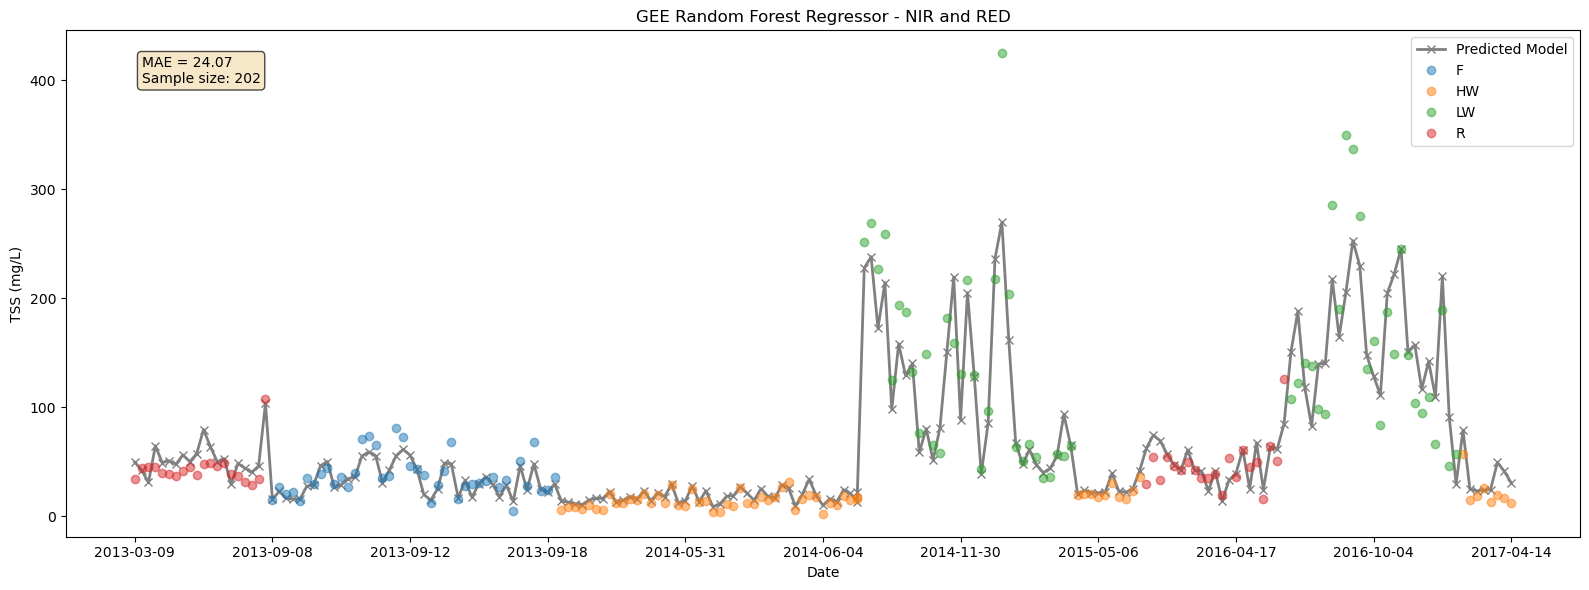

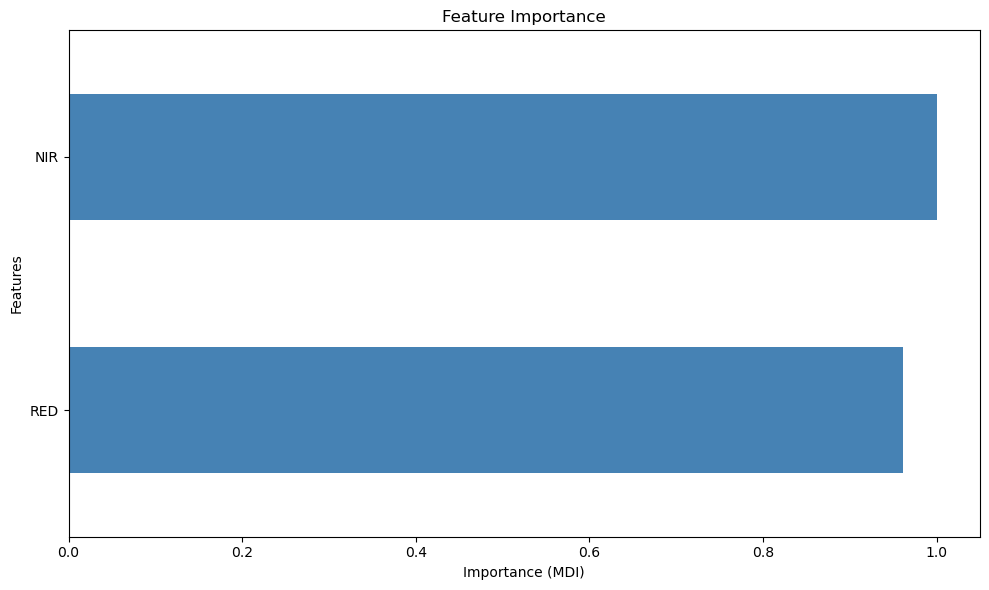


Processing: NIR, RED and GREEN (nir_red_green)

  Best params: {'maxNodes': None, 'numberOfTrees': 100, 'bagFraction': 0.5}
  CV Metrics - MAE: 23.537 | R²: 0.705
  Final Metrics - MAE: 14.844 | R²: 0.864



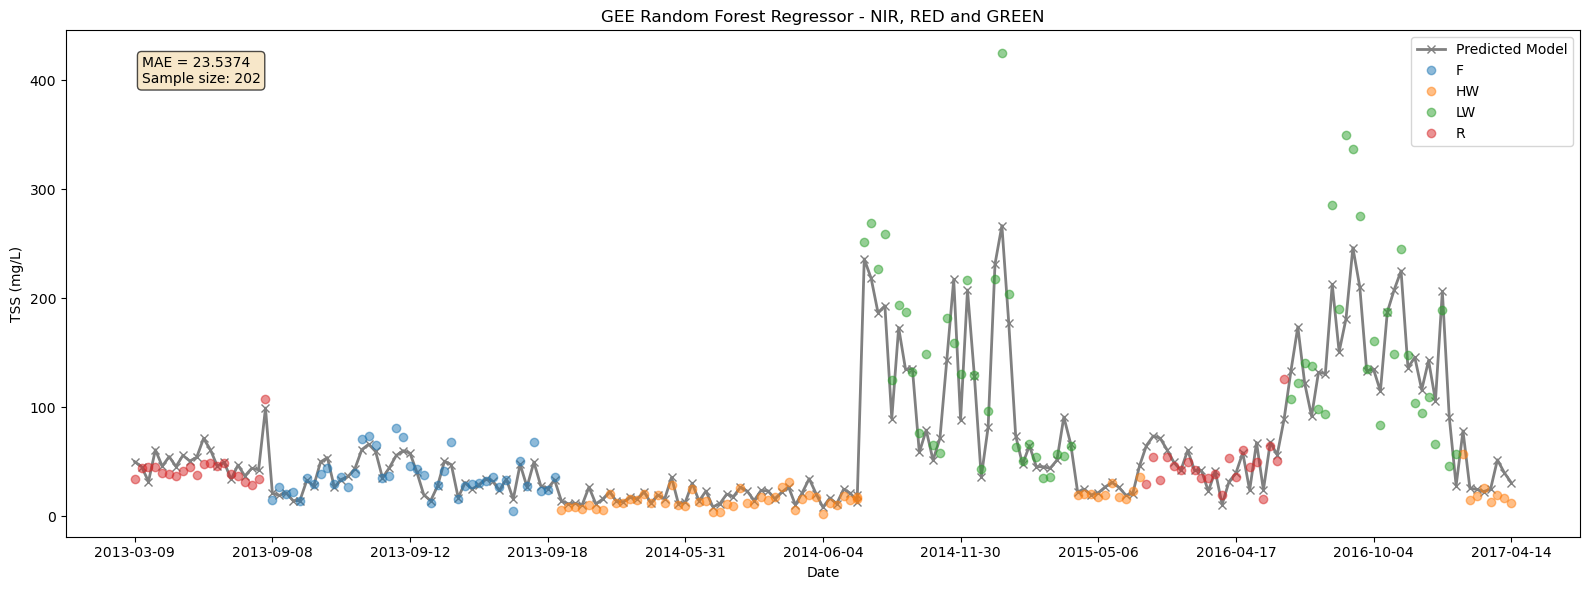

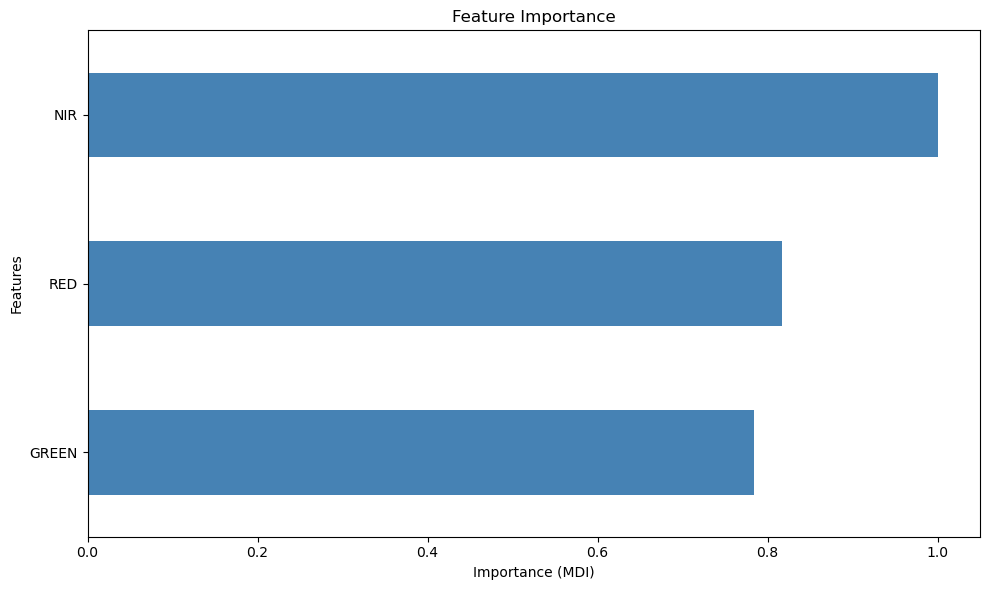


Processing: All bands (all_bands)

  Best params: {'maxNodes': None, 'numberOfTrees': 300, 'bagFraction': 0.5}
  CV Metrics - MAE: 22.267 | R²: 0.730
  Final Metrics - MAE: 12.920 | R²: 0.889



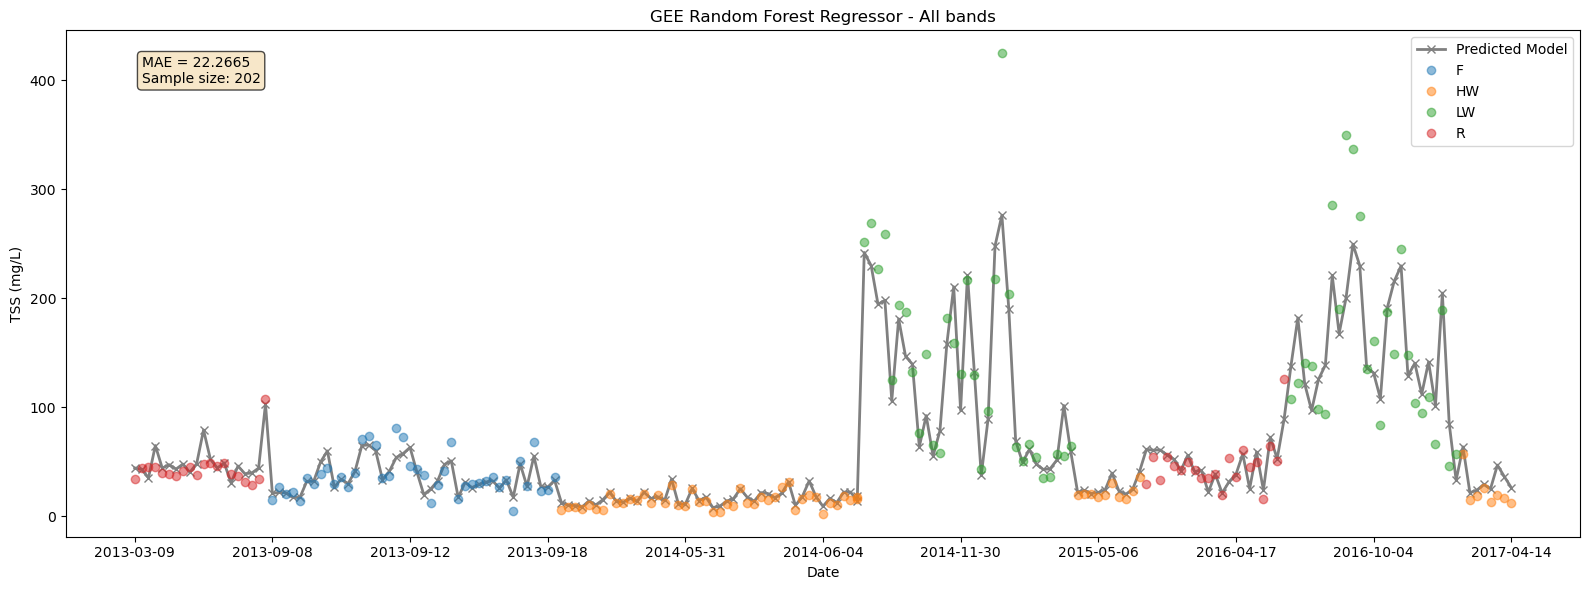

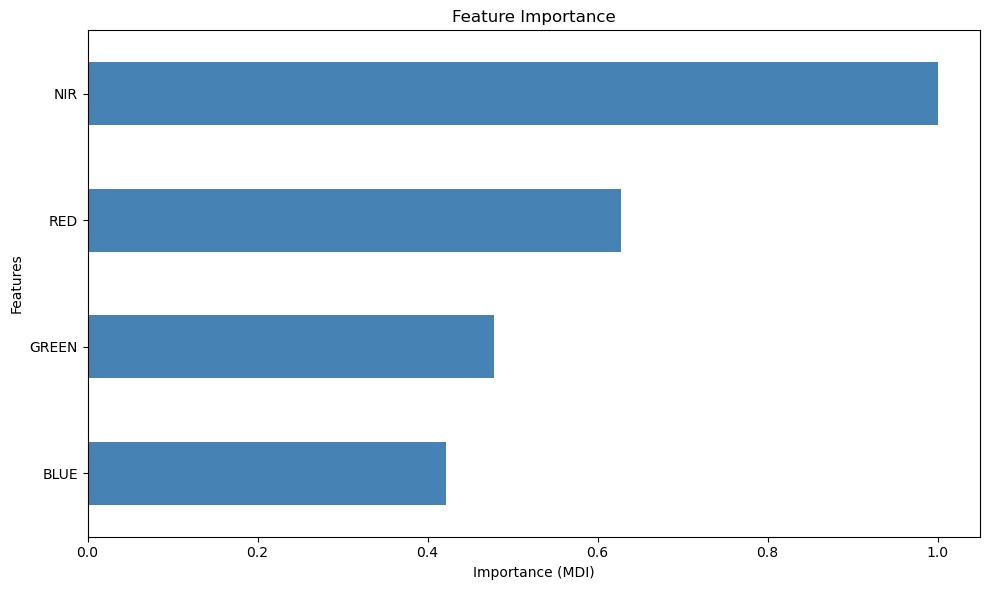


Processing: All bands + Lake (location)

  Best params: {'maxNodes': None, 'numberOfTrees': 200, 'bagFraction': 0.8}
  CV Metrics - MAE: 22.537 | R²: 0.717
  Final Metrics - MAE: 8.550 | R²: 0.943



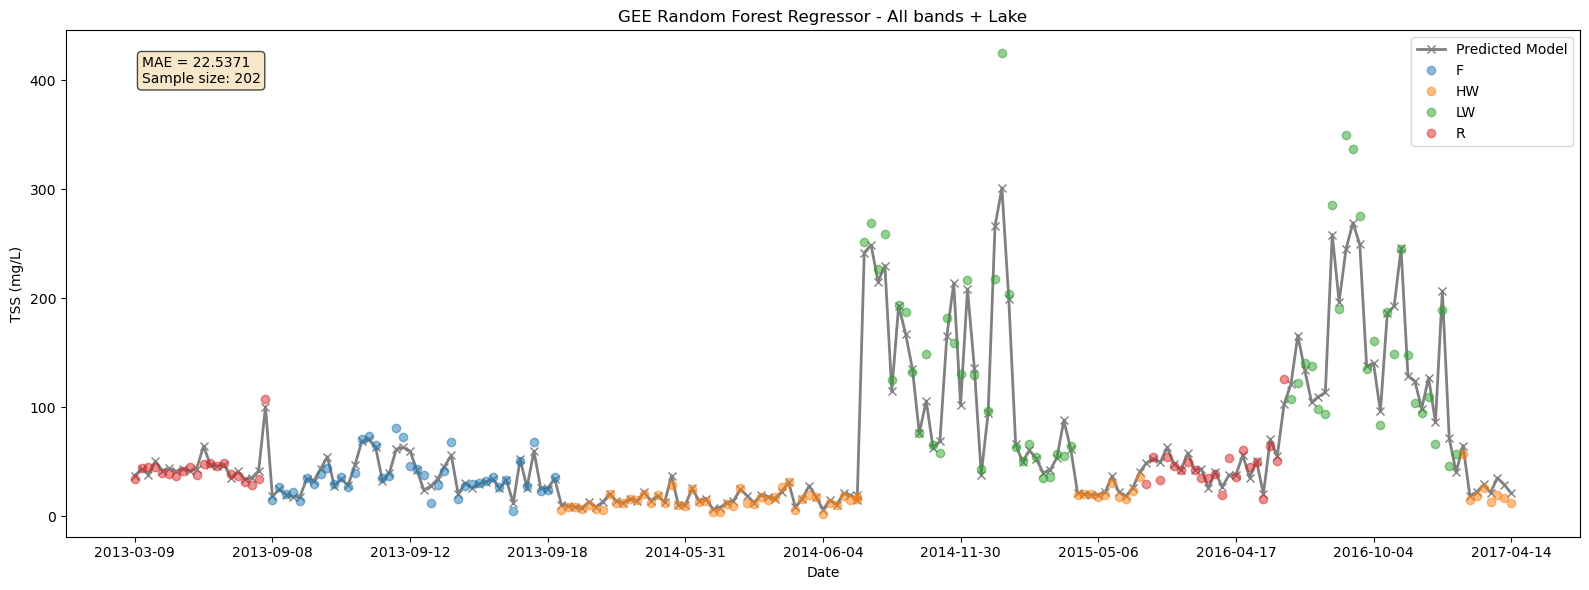

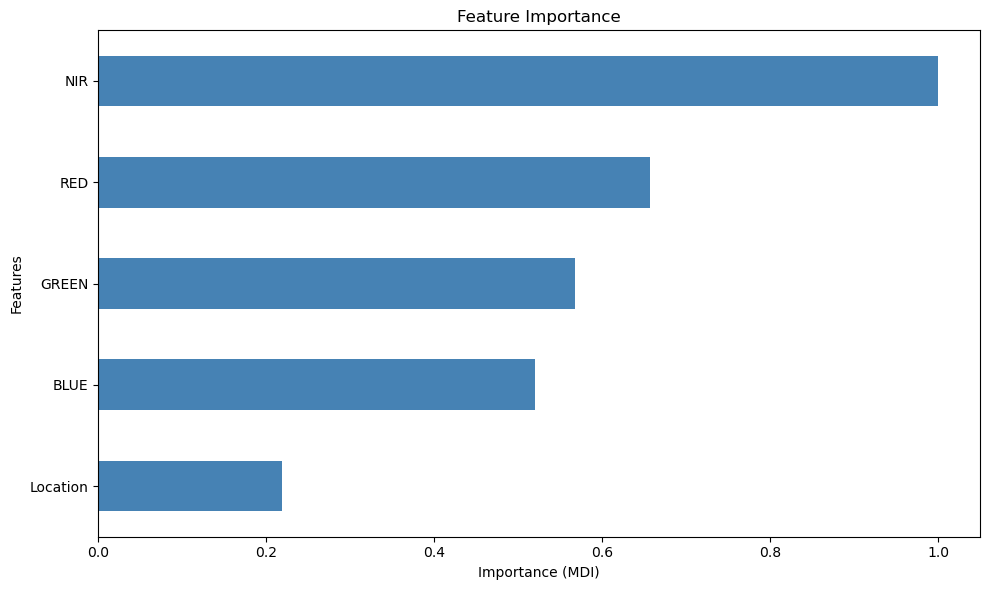


Processing: All bands + Water Period (period)

  Best params: {'maxNodes': None, 'numberOfTrees': 200, 'bagFraction': 0.8}
  CV Metrics - MAE: 20.111 | R²: 0.747
  Final Metrics - MAE: 8.218 | R²: 0.945



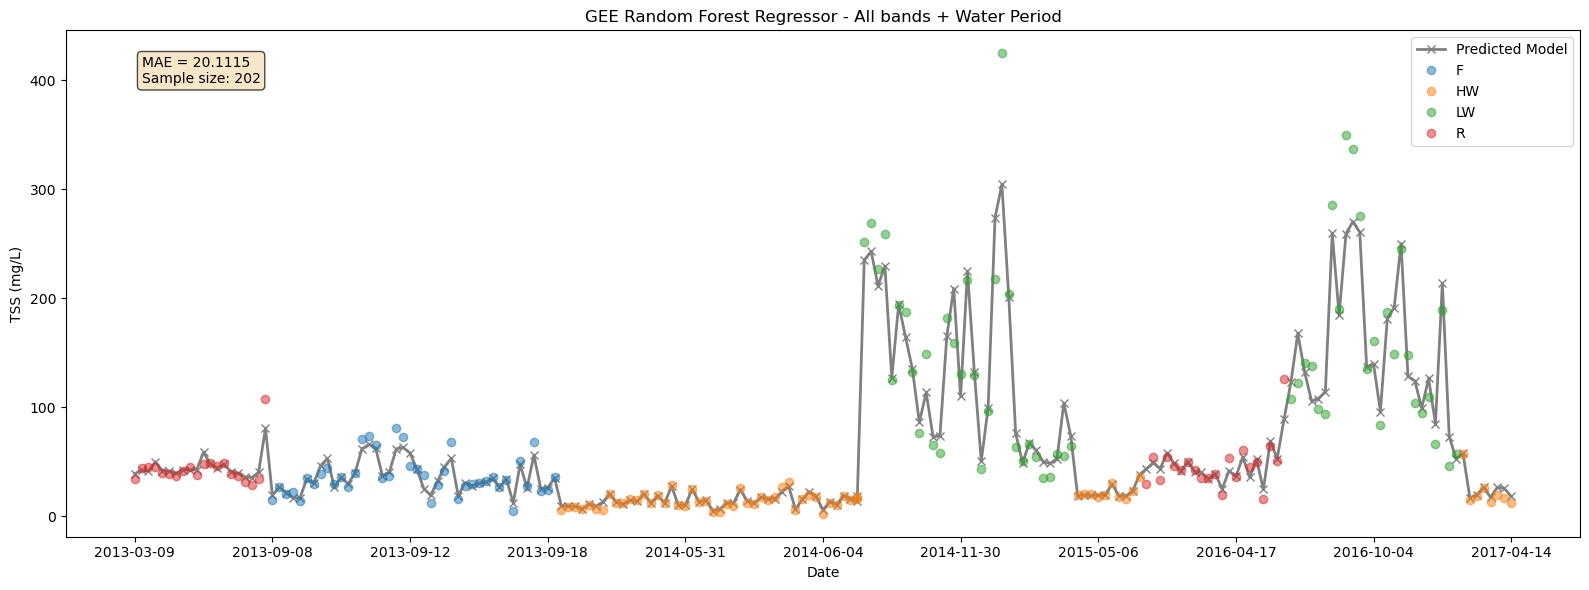

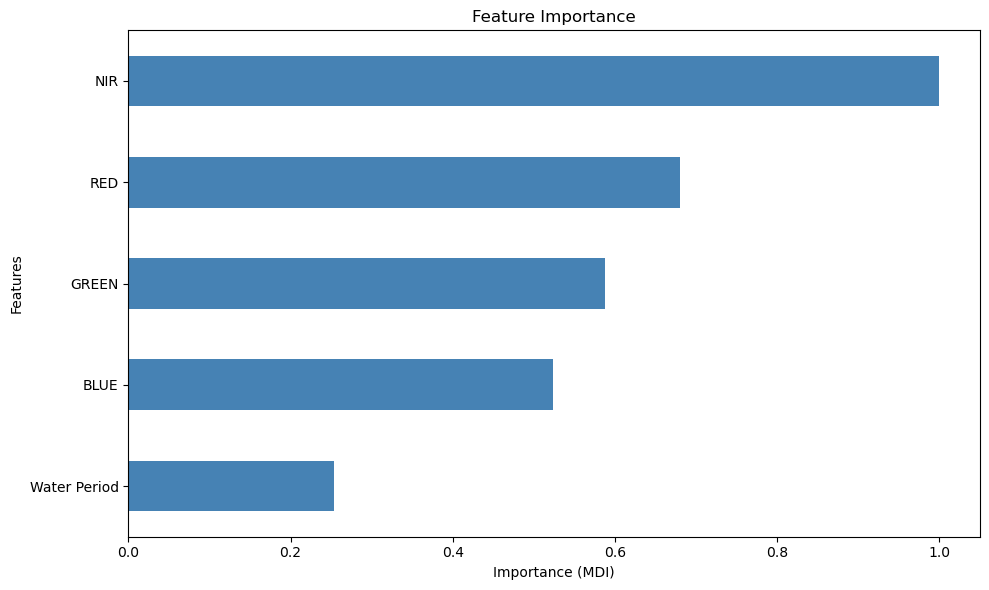


Processing: All bands + Water Period + Location (period_location)

  Best params: {'maxNodes': None, 'numberOfTrees': 500, 'bagFraction': 0.8}
  CV Metrics - MAE: 20.403 | R²: 0.748
  Final Metrics - MAE: 8.318 | R²: 0.943



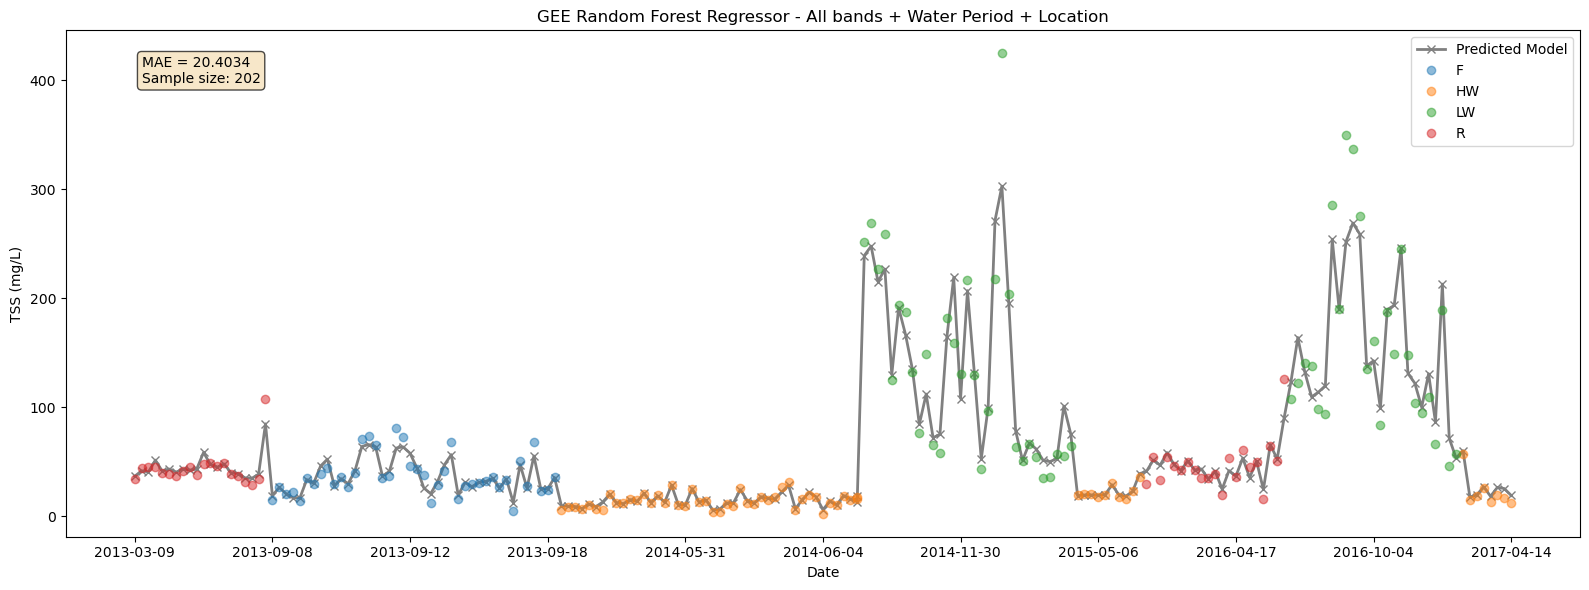

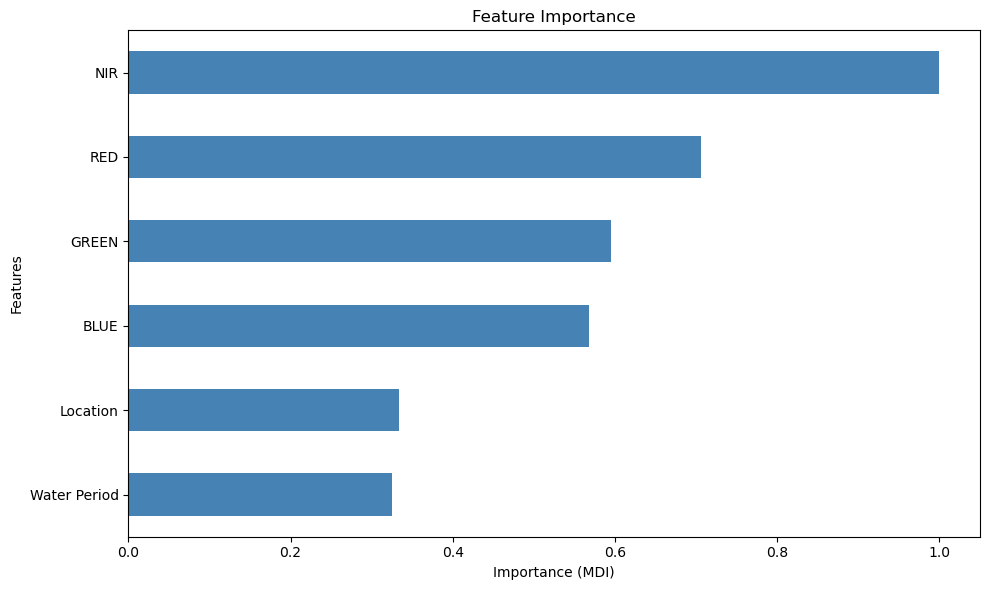

In [25]:
# Configuration
key = 'RF_GEE'
model_title = MODEL_CONFIG[key]['description']
dict_params = MODEL_CONFIG[key]['model']
param_keys = dict_params.keys()
seeds = FEATURE_GROUPS['seed']

# Main training loop
for feature_key, feature_info in FEATURE_GROUPS['multi_band'].items():
    band = feature_info['band']
    name = feature_info['name']
    list_avg_metrics = []
    list_params = []
    
    print(f"\n{'='*60}")
    print(f"Processing: {name} ({feature_key})")
    print(f"{'='*60}")
    
    # Evaluate each parameter combination
    for param_values in product(*dict_params.values()):
        params = dict(zip(param_keys, param_values))
        
        # Cross-validate this parameter combination
        avg_metrics = evaluate_parameter_combination(params, band, reg_data, seeds,key)
        list_avg_metrics.append(avg_metrics)
        list_params.append(params)
        
        # print(f"  Params: {params} | MAE: {avg_metrics['mae']:.3f} | R²: {avg_metrics['r2']:.3f}")
    
    # Find best model by MAE (then R² if tied)
    best_index, best_metrics = best_by_mae_then_r2(list_avg_metrics)
    best_params = list_params[best_index]
    
    print(f"\n  Best params: {best_params}")
    print(f"  CV Metrics - MAE: {best_metrics['mae']:.3f} | R²: {best_metrics['r2']:.3f}")
    
    # Train final model on full dataset
    trained, y_pred_df = train_final_model(best_params, band, reg_data,key)
    final_metrics = model_metrics(df_subset['TSS'], y_pred_df['classification'])
    
    print(f"  Final Metrics - MAE: {final_metrics['mae']:.3f} | R²: {final_metrics['r2']:.3f}\n")
    
    # Store results
    results['water_period']['model'][key]['multi_band'][feature_key] = {
        'metrics': final_metrics,
        'cv_metrics': best_metrics,
        'params': best_params
    }
    results['water_period']['period_filter'] = None
    
    # Generate visualizations
    prepare_time_series_plot(
        df=df_subset,
        y_pred=y_pred_df['classification'],
        cv_metrics_dict=best_metrics,
        title=f"{model_title} - {name}",
        r2_key='mae',
        exp=f"{feature_key}_{key}"
    )
    feature_importance_plot(trained=trained, exp=f"{feature_key}_{key}")

In [26]:
df_metrics, df_cv_metrics = transform_dataframe(results)

Standard Metrics DataFrame:


,Model,Group,Feature,Params,r2,mae,mse,mape,exp_var
0,RF_GEE,multi_band,nir_red,"{'maxNodes': None, 'numberOfTrees': 200, 'bagF...",0.867477,15.206180,671.684285,0.329483,0.867491
1,RF_GEE,multi_band,nir_red_green,"{'maxNodes': None, 'numberOfTrees': 100, 'bagF...",0.863653,14.843933,691.069860,0.324608,0.863864
2,RF_GEE,multi_band,all_bands,"{'maxNodes': None, 'numberOfTrees': 300, 'bagF...",0.888826,12.920339,563.481183,0.275249,0.888867
3,RF_GEE,multi_band,location,"{'maxNodes': None, 'numberOfTrees': 200, 'bagF...",0.942884,8.550017,289.488955,0.182141,0.942884
4,RF_GEE,multi_band,period,"{'maxNodes': None, 'numberOfTrees': 200, 'bagF...",0.945193,8.217552,277.784701,0.149371,0.945201



Cross-Validation Metrics DataFrame:


,Model,Group,Feature,Params,r2,mae,mse,mape,exp_var
0,RF_GEE,multi_band,nir_red,"{'maxNodes': None, 'numberOfTrees': 200, 'bagF...",0.712751,24.069958,1656.722278,0.525868,0.730275
1,RF_GEE,multi_band,nir_red_green,"{'maxNodes': None, 'numberOfTrees': 100, 'bagF...",0.705162,23.537370,1768.458157,0.521185,0.721344
2,RF_GEE,multi_band,all_bands,"{'maxNodes': None, 'numberOfTrees': 300, 'bagF...",0.729764,22.266549,1597.363239,0.476356,0.744493
3,RF_GEE,multi_band,location,"{'maxNodes': None, 'numberOfTrees': 200, 'bagF...",0.717384,22.537133,1694.473942,0.482130,0.732899
4,RF_GEE,multi_band,period,"{'maxNodes': None, 'numberOfTrees': 200, 'bagF...",0.747159,20.111474,1524.133381,0.370373,0.761545


In [27]:
df_metrics.to_csv(os.path.join(export_dir,f'model_metrics_{key}.csv'), index=False)
df_cv_metrics.to_csv(os.path.join(export_dir,f'cv_metrics_{key}.csv'), index=False)

## SVM

In [ ]:
# Configuration
key = 'SVM_GEE'
model_title = MODEL_CONFIG[key]['description']
dict_params = MODEL_CONFIG[key]['model']
param_keys = dict_params.keys()
seeds = FEATURE_GROUPS['seed']

# Main training loop
for feature_key, feature_info in FEATURE_GROUPS['multi_band'].items():
    band = feature_info['band']
    name = feature_info['name']
    list_avg_metrics = []
    list_params = []
    
    print(f"\n{'='*60}")
    print(f"Processing: {name} ({feature_key})")
    print(f"{'='*60}")
    
    # Evaluate each parameter combination
    for param_values in product(*dict_params.values()):
        params = dict(zip(param_keys, param_values))
        
        # Cross-validate this parameter combination
        avg_metrics = evaluate_parameter_combination(params, band, reg_data, seeds,key)
        list_avg_metrics.append(avg_metrics)
        list_params.append(params)
        
        # print(f"  Params: {params} | MAE: {avg_metrics['mae']:.3f} | R²: {avg_metrics['r2']:.3f}")
    
    # Find best model by MAE (then R² if tied)
    best_index, best_metrics = best_by_mae_then_r2(list_avg_metrics)
    best_params = list_params[best_index]
    
    print(f"\n  Best params: {best_params}")
    print(f"  CV Metrics - MAE: {best_metrics['mae']:.3f} | R²: {best_metrics['r2']:.3f}")
    
    # Train final model on full dataset
    trained, y_pred_df = train_final_model(best_params, band, reg_data,key)
    final_metrics = model_metrics(df_subset['TSS'], y_pred_df['classification'])
    
    print(f"  Final Metrics - MAE: {final_metrics['mae']:.3f} | R²: {final_metrics['r2']:.3f}\n")
    
    # Store results
    results['water_period']['model'][key]['multi_band'][feature_key] = {
        'metrics': final_metrics,
        'cv_metrics': best_metrics,
        'params': best_params
    }
    results['water_period']['period_filter'] = None
    
    # Generate visualizations
    prepare_time_series_plot(
        df=df_subset,
        y_pred=y_pred_df['classification'],
        cv_metrics_dict=best_metrics,
        title=f"{model_title} - {name}",
        r2_key='mae',
        exp=f"{feature_key}_{key}"
    )
    feature_importance_plot(trained=trained, exp=f"{feature_key}_{key}")


Processing: NIR and RED (nir_red)


In [ ]:
df_metrics, df_cv_metrics = transform_dataframe(results)

In [ ]:
df_metrics.to_csv(os.path.join(export_dir,f'model_metrics_{key}.csv'), index=False)
df_cv_metrics.to_csv(os.path.join(export_dir,f'cv_metrics_{key}.csv'), index=False)

## GBR

In [ ]:
# Configuration
key = 'GBR_GEE'
model_title = MODEL_CONFIG[key]['description']
dict_params = MODEL_CONFIG[key]['model']
param_keys = dict_params.keys()
seeds = FEATURE_GROUPS['seed']

# Main training loop
for feature_key, feature_info in FEATURE_GROUPS['multi_band'].items():
    band = feature_info['band']
    name = feature_info['name']
    list_avg_metrics = []
    list_params = []
    
    print(f"\n{'='*60}")
    print(f"Processing: {name} ({feature_key})")
    print(f"{'='*60}")
    
    # Evaluate each parameter combination
    for param_values in product(*dict_params.values()):
        params = dict(zip(param_keys, param_values))
        
        # Cross-validate this parameter combination
        avg_metrics = evaluate_parameter_combination(params, band, reg_data, seeds,key)
        list_avg_metrics.append(avg_metrics)
        list_params.append(params)
        
        # print(f"  Params: {params} | MAE: {avg_metrics['mae']:.3f} | R²: {avg_metrics['r2']:.3f}")
    
    # Find best model by MAE (then R² if tied)
    best_index, best_metrics = best_by_mae_then_r2(list_avg_metrics)
    best_params = list_params[best_index]
    
    print(f"\n  Best params: {best_params}")
    print(f"  CV Metrics - MAE: {best_metrics['mae']:.3f} | R²: {best_metrics['r2']:.3f}")
    
    # Train final model on full dataset
    trained, y_pred_df = train_final_model(best_params, band, reg_data,key)
    final_metrics = model_metrics(df_subset['TSS'], y_pred_df['classification'])
    
    print(f"  Final Metrics - MAE: {final_metrics['mae']:.3f} | R²: {final_metrics['r2']:.3f}\n")
    
    # Store results
    results['water_period']['model'][key]['multi_band'][feature_key] = {
        'metrics': final_metrics,
        'cv_metrics': best_metrics,
        'params': best_params
    }
    results['water_period']['period_filter'] = None
    
    # Generate visualizations
    prepare_time_series_plot(
        df=df_subset,
        y_pred=y_pred_df['classification'],
        cv_metrics_dict=best_metrics,
        title=f"{model_title} - {name}",
        r2_key='mae',
        exp=f"{feature_key}_{key}"
    )
    feature_importance_plot(trained=trained, exp=f"{feature_key}_{key}")

In [ ]:
df_metrics, df_cv_metrics = transform_dataframe(results)

In [ ]:
df_metrics.to_csv(os.path.join(export_dir,f'model_metrics_{key}.csv'), index=False)
df_cv_metrics.to_csv(os.path.join(export_dir,f'cv_metrics_{key}.csv'), index=False)